<a href="https://colab.research.google.com/github/gguex/ISH_ressources_cours_ML/blob/main/TP03_modeles_lineaires_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning (Lettres) TP 3 : Modèles linéaires pour la classification

Dans ce troisième TP, nous allons faire des régressions linéaires et logistiques pour de la classification, et les comparer à une référence naïve ainsi qu'aux $k$ plus proches voisins. Il y aura deux parties :

* La classification d'une variable binaire
* La classification d'une variable à classes multiples

Un exercice consistera à refaire ces modèles, afin d'optimiser cette fois la mesure F1, sur un nouveau jeu de données.

Nous réutilisons les outils des deux premiers TP : `pandas` pour les tableaux, `seaborn` pour les graphiques, et les pipelines et `GridSearchCV` de `scikit-learn`. Les seules nouveautés sont deux modèles (`LogisticRegression` et `KNeighborsClassifier`) et les mesures de performance pour la classification.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
# Les modèles
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
# Pour séparer le jeu de données et chercher les hyperparamètres
from sklearn.model_selection import train_test_split, GridSearchCV
# Pour standardiser, et enchaîner ce prétraitement avec un modèle
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# Nos différentes mesures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Le même style de graphiques qu'au TP 1
sns.set_theme(style="whitegrid", palette="colorblind")

In [ ]:
# Connexion à Google Drive sur Colab ; dossier local sinon
try:
    from google.colab import drive
except ImportError:
    data_path = Path("data") / "TP3"
else:
    drive.mount("/content/drive")
    data_path = Path("/content/drive/MyDrive/Colab Notebooks/data/TP3")

Mounted at /content/drive


---

## 1. Variable binaire

Nous allons utiliser ici le jeu de données "BreastCancer.csv" (https://www.rdocumentation.org/packages/mlbench/versions/2.1-3/topics/BreastCancer) possédant une variable "Class" indiquant si la tumeur prélevée est bénigne ou maligne. Les autres variables sont numériques.

On commence par charger le jeu de données :

In [ ]:
file_path = data_path / "BreastCancer.csv"
data = pd.read_csv(file_path)
data.head()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,benign
1,1002945,5,4,4,5,7,10,3,2,1,benign
2,1015425,3,1,1,1,2,2,3,1,1,benign
3,1016277,6,8,8,1,3,4,3,7,1,benign
4,1017023,4,1,1,3,2,1,3,1,1,benign


On isole nos entrées et sorties, et on transforme ces dernières en une variable binaire avec "benign" = 0 et "malignant" = 1. Comme au TP 1, `value_counts()` donne les effectifs de chaque classe.

In [ ]:
inputs = data.drop(columns=["Id", "Class"])
outputs = (data["Class"] == "malignant") * 1
outputs.value_counts()

,count
Class,
0,444
1,239


On va maintenant séparer notre jeu de données en jeu de développement et de test, avec l'option `stratify=outputs`, c'est-à-dire qu'on prend garde à ce que les classes contenues dans `outputs` soient réparties de manière similaire dans les deux jeux de données.

In [ ]:
inputs_dev, inputs_test, outputs_dev, outputs_test = \
    train_test_split(inputs, outputs, test_size=0.2, stratify=outputs,
                     random_state=42)
# On observe les proportions
print(f"Proportion de malignant dans dev : {outputs_dev.mean():.2%}")
print(f"Proportion de malignant dans test : {outputs_test.mean():.2%}")

Proportion de malignant dans dev : 34.98%
Proportion de malignant dans test : 35.04%


### Les mesures de performance

Nous allons comparer plusieurs modèles avec quatre mesures : l'exactitude, la précision, le rappel et le F1 (voir le cours). Pour ne pas répéter le même code, nous écrivons une fonction qui les calcule et les renvoie dans un dictionnaire. Nous pourrons ainsi ranger les résultats dans un DataFrame. Par défaut, la précision, le rappel et le F1 sont calculés pour la classe 1 (ici "malignant").

In [ ]:
def compute_scores(outputs_true, outputs_pred, average="binary"):
    return {
        "Exactitude": accuracy_score(outputs_true, outputs_pred),
        "Précision": precision_score(outputs_true, outputs_pred,
                                     average=average, zero_division=0),
        "Rappel": recall_score(outputs_true, outputs_pred, average=average),
        "F1": f1_score(outputs_true, outputs_pred, average=average),
    }

### La référence naïve

Avant d'entraîner un modèle, calculons ce que l'on obtient sans rien apprendre : la **référence naïve** prédit toujours la classe majoritaire du jeu de développement (`mode()` donne la valeur la plus fréquente).

In [ ]:
majority_class = outputs_dev.mode()[0]
outputs_naive_test = np.full(len(outputs_test), majority_class)
compute_scores(outputs_test, outputs_naive_test)

{'Exactitude': 0.6496350364963503, 'Précision': 0.0, 'Rappel': 0.0, 'F1': 0.0}

L'exactitude est déjà de 65% sans utiliser aucune variable, mais le rappel est nul : aucune tumeur maligne n'est détectée. Un modèle n'est intéressant que s'il fait nettement mieux que cette référence.

### La régression linéaire

On va maintenant entraîner un modèle linéaire sur le jeu de développement :

In [ ]:
linear_reg = LinearRegression()
linear_reg.fit(inputs_dev, outputs_dev)

LinearRegression()

Les prédictions $\widehat{y}_i = 1$ s'obtiennent ssi $\widehat{z}_i > 0.5$. On calcule ensuite nos mesures, pour les jeux de développement et de test, et on les range dans un DataFrame :

In [ ]:
# Les prédictions
outputs_lin_dev = (linear_reg.predict(inputs_dev) > 0.5) * 1
outputs_lin_test = (linear_reg.predict(inputs_test) > 0.5) * 1
# Les scores
pd.DataFrame({"dev": compute_scores(outputs_dev, outputs_lin_dev),
              "test": compute_scores(outputs_test, outputs_lin_test)})

,dev,test
Exactitude,0.967033,0.941606
Précision,0.977901,0.916667
Rappel,0.926702,0.916667
F1,0.951613,0.916667


### La régression logistique

La régression logistique de `scikit-learn` est régularisée par défaut (Ridge). Son hyperparamètre `C` est l'**inverse** de $\lambda$ : plus `C` est petit, plus la régularisation est forte. Comme au TP 2, on standardise les variables dans une pipeline, puis on cherche $C \in [0.001, 0.5]$ par cross-validation avec `GridSearchCV`.

On observe cette fois plusieurs mesures. L'argument `refit` indique selon laquelle le meilleur modèle doit être choisi et réentraîné : ici le rappel, car ne pas détecter une tumeur maligne est l'erreur la plus grave. Pour une classification, `cv=k` crée des folds stratifiés.

In [ ]:
# Paramètres pour la CV
params = np.linspace(0.001, 0.5, 50)
k = 5
# Pipeline et recherche sur grille avec CV
logistic_pipeline = make_pipeline(StandardScaler(),
                                  LogisticRegression())
param_grid = {"logisticregression__C": params}
grid_search = GridSearchCV(logistic_pipeline,
                           param_grid,
                           cv=k,
                           scoring=["accuracy", "precision", "recall", "f1"],
                           refit="recall")
grid_search.fit(inputs_dev, outputs_dev)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': array([0.001     , 0.01118367, 0.02136735, 0.03155102, 0.04173469,
       0.05191837, 0.06210204, 0.07228571, 0.08246939, 0.09265306,
       0.10283673, 0.11302041, 0.12320408, 0.13338776, 0.14357143,
       0.1537551 , 0.16393878,...
       0.20467347, 0.21485714, 0.22504082, 0.23522449, 0.24540816,
       0.25559184, 0.26577551, 0.27595918, 0.28614286, 0.29632653,
       0.3065102 , 0.31669388, 0.32687755, 0.33706122, 0.3472449 ,
       0.35742857, 0.36761224, 0.37779592, 0.38797959, 0.39816327,
       0.40834694, 0.41853061, 0.42871429, 0.43889796, 0.44908163,
       0.45926531, 0.46944898, 0.47963265, 0.48981633, 0.5       ])},
             refit='recall', scoring=['accuracy', 'precision', 'recall', 'f1'])

On range les scores (moyenne sur les folds de validation) dans un DataFrame indexé par $C$. Seaborn trace alors une courbe par colonne :

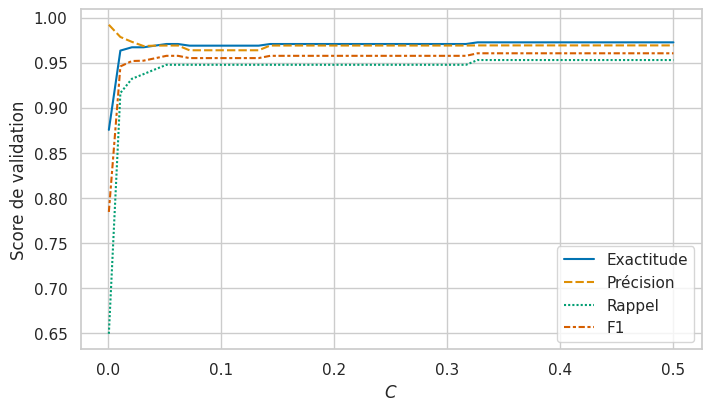

In [ ]:
cv_scores = pd.DataFrame({"Exactitude": grid_search.cv_results_["mean_test_accuracy"],
                          "Précision": grid_search.cv_results_["mean_test_precision"],
                          "Rappel": grid_search.cv_results_["mean_test_recall"],
                          "F1": grid_search.cv_results_["mean_test_f1"]},
                         index=params)

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
sns.lineplot(data=cv_scores, ax=ax)
ax.set(xlabel="$C$", ylabel="Score de validation")
plt.show()

Avec une très forte régularisation ($C$ proche de 0), le modèle prédit rarement "malignant" : la précision est excellente, mais le rappel est faible. Les mesures ne racontent pas la même histoire, d'où l'importance de choisir celle qui correspond au problème.

`GridSearchCV` a retenu le meilleur hyperparamètre selon le rappel, et a réentraîné ce modèle sur tout le jeu de développement (`best_estimator_`). On calcule nos mesures :

In [ ]:
print(grid_search.best_params_)
best_log_reg = grid_search.best_estimator_
# Les prédictions
outputs_log_dev = best_log_reg.predict(inputs_dev)
outputs_log_test = best_log_reg.predict(inputs_test)
# Les scores
pd.DataFrame({"dev": compute_scores(outputs_dev, outputs_log_dev),
              "test": compute_scores(outputs_test, outputs_log_test)})

{'logisticregression__C': np.float64(0.32687755102040816)}


,dev,test
Exactitude,0.974359,0.963504
Précision,0.968254,0.921569
Rappel,0.958115,0.979167
F1,0.963158,0.949495


### Les $k$ plus proches voisins

Essayons maintenant un modèle non linéaire : les $k$ plus proches voisins (kNN). Comme cette méthode repose sur des distances entre individus, la standardisation est indispensable : sans elle, les variables avec de grandes valeurs domineraient la distance. La pipeline est la même, seul le modèle change. L'hyperparamètre est le nombre de voisins $k$ (`n_neighbors`), que l'on cherche entre 1 et 30, toujours selon le rappel.

In [ ]:
n_neighbors = np.arange(1, 31)
knn_pipeline = make_pipeline(StandardScaler(),
                             KNeighborsClassifier())
param_grid_knn = {"kneighborsclassifier__n_neighbors": n_neighbors}
grid_search_knn = GridSearchCV(knn_pipeline,
                               param_grid_knn,
                               cv=k,
                               scoring="recall")
grid_search_knn.fit(inputs_dev, outputs_dev)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('kneighborsclassifier',
                                        KNeighborsClassifier())]),
             param_grid={'kneighborsclassifier__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])},
             scoring='recall')

{'kneighborsclassifier__n_neighbors': np.int64(7)}


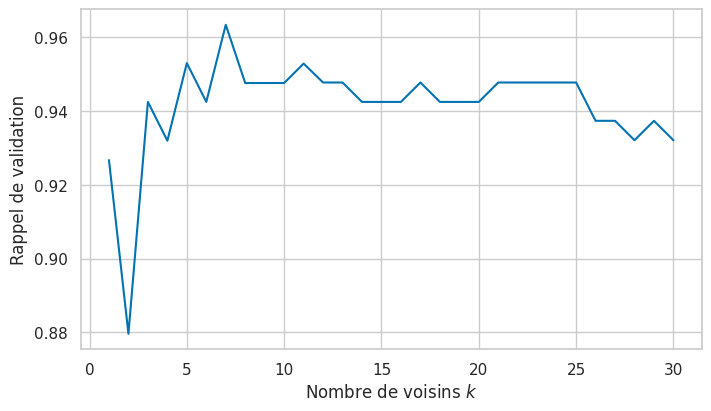

In [ ]:
print(grid_search_knn.best_params_)

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
sns.lineplot(x=n_neighbors, y=grid_search_knn.cv_results_["mean_test_score"], ax=ax)
ax.set(xlabel="Nombre de voisins $k$", ylabel="Rappel de validation")
plt.show()

In [ ]:
best_knn = grid_search_knn.best_estimator_
outputs_knn_test = best_knn.predict(inputs_test)

### Comparaison des modèles

Pour **choisir** entre la régression logistique et le kNN, on compare leurs scores de validation (`best_score_`), et non leurs scores de test : le jeu de test ne sert qu'à estimer, à la fin, la performance du modèle retenu.

In [ ]:
print(f"Rappel de validation : logistique = {grid_search.best_score_:.2%}, "
      f"kNN = {grid_search_knn.best_score_:.2%}")

Rappel de validation : logistique = 95.29%, kNN = 96.34%


Voici maintenant les mesures de tous nos modèles sur le jeu de test, rangées dans un DataFrame (`.T` transpose le tableau pour avoir un modèle par ligne) :

In [ ]:
test_scores = pd.DataFrame({
    "Référence naïve": compute_scores(outputs_test, outputs_naive_test),
    "Régression linéaire": compute_scores(outputs_test, outputs_lin_test),
    "Régression logistique": compute_scores(outputs_test, outputs_log_test),
    "kNN": compute_scores(outputs_test, outputs_knn_test),
}).T
test_scores.round(3)

,Exactitude,Précision,Rappel,F1
Référence naïve,0.650,0.000,0.000,0.000
Régression linéaire,0.942,0.917,0.917,0.917
Régression logistique,0.964,0.922,0.979,0.949
kNN,0.956,0.920,0.958,0.939


Les trois modèles font beaucoup mieux que la référence naïve. Entre eux, les différences sont faibles : le jeu de test ne contient que 137 individus, et une seule tumeur classée différemment change le rappel de 2%. On ne peut donc pas conclure qu'un modèle est réellement meilleur sur la base de ces petits écarts.

### Matrice de confusion et erreurs

La **matrice de confusion** croise les vraies classes et les classes prédites. `pd.crosstab` construit ce tableau, et `sns.heatmap` l'affiche. Nous en faisons une fonction, que nous réutiliserons :

In [ ]:
def plot_confusion(outputs_true, outputs_pred):
    confusion = pd.crosstab(outputs_true, outputs_pred,
                            rownames=["Vraie classe"],
                            colnames=["Classe prédite"])
    fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
    sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    plt.show()

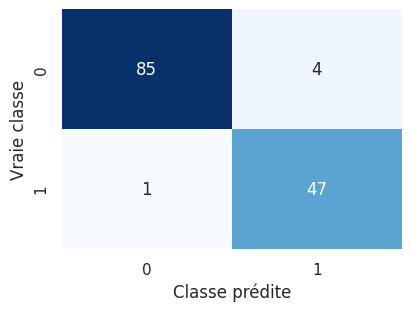

In [ ]:
# Le modèle logistique sur le jeu de test (0 = benign, 1 = malignant)
plot_confusion(outputs_test, outputs_log_test)

Il est toujours instructif d'aller regarder les individus mal classés :

In [ ]:
errors = outputs_test != outputs_log_test
data.loc[inputs_test[errors].index]

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
244,1017023,6,3,3,5,3,10,3,5,3,benign
285,616240,5,3,4,3,4,5,4,7,1,benign
1,1002945,5,4,4,5,7,10,3,2,1,benign
419,1293439,6,9,7,5,5,8,4,2,1,benign
12,1041801,5,3,3,3,2,3,4,4,1,malignant


Ces tumeurs ont-elles quelque chose de particulier ? Comparez leurs valeurs avec les moyennes de chaque classe, données par `data.groupby("Class").mean(numeric_only=True)`.

---

## 2. Classes multiples

La même procédure peut être effectuée sur un jeu de données contenant une variable avec de multiples classes, en l'occurrence les Iris de Fisher, déjà vus au TP 1, avec le type d'Iris dans "variety". On charge les données :

In [ ]:
file_path = data_path / "iris.csv"
data = pd.read_csv(file_path)
inputs = data.drop(columns=["variety"])
outputs = data["variety"]

On utilise `pd.get_dummies` pour recoder notre variable catégorielle en vecteurs one-hot. Le nom des colonnes nous donne l'ordre des classes.

In [ ]:
outputs_1hot = pd.get_dummies(outputs)
classes = outputs_1hot.columns.to_numpy()
print(classes)
outputs_1hot.head()

['Setosa' 'Versicolor' 'Virginica']


,Setosa,Versicolor,Virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


Séparons en jeu de développement et de test, tout en stratifiant selon `outputs` :

In [ ]:
inputs_dev, inputs_test, outputs_dev, outputs_test, outputs_1hot_dev, outputs_1hot_test = \
    train_test_split(inputs, outputs, outputs_1hot, test_size=0.2,
                     stratify=outputs, random_state=42)

### Régressions linéaires

Comme vu au cours, on entraîne une régression linéaire par classe, chacune essayant de prédire une des colonnes one-hot. `LinearRegression` accepte directement plusieurs colonnes en sortie : elle entraîne alors une régression par colonne.

In [ ]:
multi_linear_reg = LinearRegression()
multi_linear_reg.fit(inputs_dev, outputs_1hot_dev)
# Les sorties des 3 régressions pour les 5 premiers individus de test
multi_linear_reg.predict(inputs_test)[:5]

array([[ 0.83865855,  0.34448494, -0.18314349],
       [ 0.04763351,  0.31005408,  0.64231242],
       [ 0.22788681,  0.65233518,  0.11977801],
       [ 0.21455517,  0.68450248,  0.10094235],
       [ 0.88318654,  0.26433187, -0.14751841]])

La classe prédite est celle dont la régression donne la plus grande sortie. `np.argmax(..., axis=1)` donne, pour chaque ligne, le numéro de la colonne la plus élevée :

In [ ]:
outputs_lin_dev = classes[np.argmax(multi_linear_reg.predict(inputs_dev), axis=1)]
outputs_lin_test = classes[np.argmax(multi_linear_reg.predict(inputs_test), axis=1)]
print(outputs_lin_test)

['Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Virginica'
 'Setosa' 'Setosa' 'Virginica' 'Virginica' 'Versicolor' 'Virginica'
 'Virginica' 'Virginica' 'Setosa' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Versicolor' 'Versicolor'
 'Virginica' 'Virginica' 'Virginica' 'Setosa' 'Virginica' 'Setosa']


Avec plusieurs classes, la précision, le rappel et le F1 se calculent pour chaque classe. On les résume par leur moyenne sur les classes, avec l'option `average="macro"` : on obtient notamment le **F1 macro**. Notre fonction `compute_scores` prévoit cet argument :

In [ ]:
pd.DataFrame({"dev": compute_scores(outputs_dev, outputs_lin_dev, average="macro"),
              "test": compute_scores(outputs_test, outputs_lin_test, average="macro")})

,dev,test
Exactitude,0.866667,0.766667
Précision,0.868687,0.776557
Rappel,0.866667,0.766667
F1,0.866332,0.761296


### Régression logistique multinomiale

On va refaire tout cela avec une régression logistique multinomiale régularisée, avec $C \in [0.001, 1]$. Lorsqu'il y a plus de deux classes, `LogisticRegression` utilise automatiquement la fonction *softmax*. La pipeline est exactement la même que dans la première partie ; seul le score change, avec `"f1_macro"`.

In [ ]:
# Paramètres pour la CV
params = np.linspace(0.001, 1, 50)
# Pipeline et recherche sur grille avec CV
logistic_pipeline = make_pipeline(StandardScaler(),
                                  LogisticRegression())
param_grid = {"logisticregression__C": params}
grid_search = GridSearchCV(logistic_pipeline,
                           param_grid,
                           cv=k,
                           scoring=["accuracy", "f1_macro"],
                           refit="f1_macro")
grid_search.fit(inputs_dev, outputs_dev)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': array([0.001     , 0.02138776, 0.04177551, 0.06216327, 0.08255102,
       0.10293878, 0.12332653, 0.14371429, 0.16410204, 0.1844898 ,
       0.20487755, 0.22526531, 0.24565306, 0.26604082, 0.28642857,
       0.30681633, 0.32720408,...
       0.4087551 , 0.42914286, 0.44953061, 0.46991837, 0.49030612,
       0.51069388, 0.53108163, 0.55146939, 0.57185714, 0.5922449 ,
       0.61263265, 0.63302041, 0.65340816, 0.67379592, 0.69418367,
       0.71457143, 0.73495918, 0.75534694, 0.77573469, 0.79612245,
       0.8165102 , 0.83689796, 0.85728571, 0.87767347, 0.89806122,
       0.91844898, 0.93883673, 0.95922449, 0.97961224, 1.        ])},
             refit='f1_macro', scoring=['accuracy', 'f1_macro'])

On peut maintenant faire le graphique de nos mesures en fonction de $C$ :

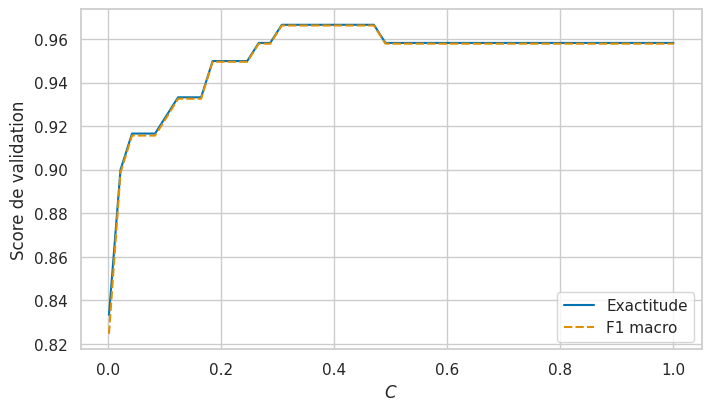

In [ ]:
cv_scores = pd.DataFrame({"Exactitude": grid_search.cv_results_["mean_test_accuracy"],
                          "F1 macro": grid_search.cv_results_["mean_test_f1_macro"]},
                         index=params)

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
sns.lineplot(data=cv_scores, ax=ax)
ax.set(xlabel="$C$", ylabel="Score de validation")
plt.show()

Les deux courbes sont presque confondues : les classes sont ici parfaitement équilibrées (50 fleurs par espèce), et l'exactitude n'est alors pas trompeuse. On retient le meilleur modèle selon le F1 macro, et on compare à la régression linéaire :

In [ ]:
print(grid_search.best_params_)
best_log_reg = grid_search.best_estimator_
# Les prédictions
outputs_log_dev = best_log_reg.predict(inputs_dev)
outputs_log_test = best_log_reg.predict(inputs_test)
# Les scores
pd.DataFrame({"dev": compute_scores(outputs_dev, outputs_log_dev, average="macro"),
              "test": compute_scores(outputs_test, outputs_log_test, average="macro")})

{'logisticregression__C': np.float64(0.30681632653061225)}


,dev,test
Exactitude,0.966667,0.933333
Précision,0.967419,0.933333
Rappel,0.966667,0.933333
F1,0.966646,0.933333


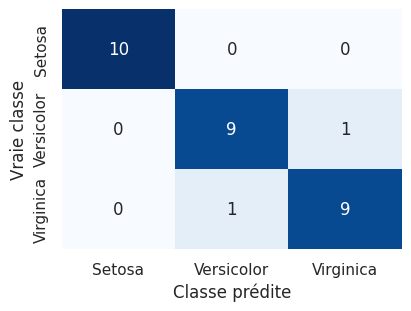

In [ ]:
plot_confusion(outputs_test, outputs_log_test)

### Les zones de décision

Finalement, on va afficher les zones de décision de notre modèle. Il s'agit pour cela de créer les points d'une grille sur les variables "petal.length" et "petal.width" (les variables associées aux sépales étant maintenues constantes sur leur moyenne), puis de calculer la prédiction du modèle pour chacun de ces points. `pd.merge(..., how="cross")` construit toutes les combinaisons des deux colonnes.

In [ ]:
# Une grille sur les deux variables des pétales
petal_length = pd.DataFrame(
    {"petal.length": np.linspace(data["petal.length"].min(),
                                 data["petal.length"].max(), 100)})
petal_width = pd.DataFrame(
    {"petal.width": np.linspace(data["petal.width"].min(),
                                data["petal.width"].max(), 100)})
grid = pd.merge(petal_length, petal_width, how="cross")

# Les sépales sont fixés à leur moyenne
grid["sepal.length"] = data["sepal.length"].mean()
grid["sepal.width"] = data["sepal.width"].mean()

# La prédiction du modèle pour chaque point (colonnes dans le même ordre que inputs)
grid["prediction"] = best_log_reg.predict(grid[inputs.columns])
grid.head()

,petal.length,petal.width,sepal.length,sepal.width,prediction
0,1.0,0.100000,5.843333,3.057333,Setosa
1,1.0,0.124242,5.843333,3.057333,Setosa
2,1.0,0.148485,5.843333,3.057333,Setosa
3,1.0,0.172727,5.843333,3.057333,Setosa
4,1.0,0.196970,5.843333,3.057333,Setosa


On superpose ensuite deux nuages de points, comme au TP 1 : les points de la grille, colorés selon la classe prédite, puis les fleurs, colorées selon leur vraie classe.

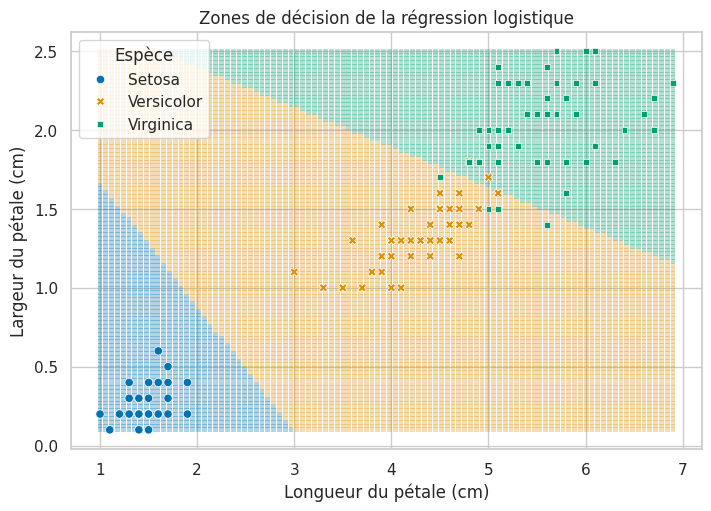

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
# Les zones : les points de la grille, en transparence
sns.scatterplot(data=grid, x="petal.length", y="petal.width",
                hue="prediction", hue_order=classes,
                marker="s", s=12, alpha=0.3, linewidth=0, legend=False, ax=ax)
# Les fleurs
sns.scatterplot(data=data, x="petal.length", y="petal.width",
                hue="variety", hue_order=classes, style="variety", ax=ax)
ax.set(xlabel="Longueur du pétale (cm)", ylabel="Largeur du pétale (cm)",
       title="Zones de décision de la régression logistique")
ax.legend(title="Espèce")
plt.show()

---

## Exercice

Dans cet exercice, vous allez effectuer la même procédure que dans la première partie, mais sur le jeu de données "PimaIndiansDiabetes.csv" (plus d'infos : https://www.rdocumentation.org/packages/mlbench/versions/2.1-3/topics/PimaIndiansDiabetes) et pour optimiser la mesure F1.

* La variable dépendante est "diabetes", qui peut être "pos" ou "neg". Toutes les autres variables sont numériques.
* Calculez d'abord les mesures de la référence naïve sur le jeu de test.
* Il s'agira ensuite de faire une régression linéaire, une régression logistique régularisée et un kNN. À vous de trouver les intervalles des hyperparamètres à tester.
* La mesure à optimiser est la mesure F1 (`scoring="f1"`).
* Rassemblez les mesures des modèles sur le jeu de test dans un DataFrame, et affichez la matrice de confusion du meilleur.

Reprenez le code de la première partie, y compris les fonctions `compute_scores` et `plot_confusion` : il ne s'agit pas de tout réécrire. Bonne chance !

In [ ]:
file_path = data_path / "PimaIndiansDiabetes.csv"
data = pd.read_csv(file_path)
data.head()

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,pos
1,1,85,66,29,0,26.6,0.351,31,neg
2,8,183,64,0,0,23.3,0.672,32,pos
3,1,89,66,23,94,28.1,0.167,21,neg
4,0,137,40,35,168,43.1,2.288,33,pos
